In [1]:
from scipy.stats import multivariate_normal
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

np.random.seed(42)

import os

# Create directory if it doesn't exist
os.makedirs("DATA", exist_ok=True)

n_samples = 100000

# Problem setup — Wing
The Wing problem discretizes the Fredholm integral equation of the first kind:
\begin{equation}
\int_{0}^{1} K(s,t)\, f(t)\, dt = g(s),
\end{equation}
where the kernel is given by
\begin{equation}
K(s,t) = t\, e^{-s t^2},
\end{equation}
the exact right-hand side is
\begin{equation}
g(s) = \frac{e^{-s/9} - e^{-4s/9}}{2s},
\end{equation}
and the true solution is discontinuous:
\begin{equation}
f(t) =
\begin{cases}
1, & \tfrac{1}{3} < t < \tfrac{2}{3}, \\
0, & \text{otherwise.}
\end{cases}
\end{equation}

## Set up parameters

In [2]:
n       = 50
m       = 20
t       = np.linspace(0, 1, n)    # parameter grid
s       = np.linspace(0, 1, m)    # data grid
dt      = t[1] - t[0]

sigma_d = 0.01
Cd      = sigma_d**2 * np.eye(m)
Cd_inv  = np.linalg.inv(Cd)

## True parameters $z_{\text{true}}$

In [3]:
# ─────────────────────────────────────────────────────────────
# 1. True parameters — discontinuous rectangular pulse
# ─────────────────────────────────────────────────────────────
def z_true_fn(t):
    z = np.zeros_like(t, dtype=float)
    z[(t > 1.0/3.0) & (t < 2.0/3.0)] = 1.0
    return z

# ─────────────────────────────────────────────────────────────
# 2. Forward operator G and exact rhs
# ─────────────────────────────────────────────────────────────
def build_G(s, t):
    """
    G[i,j] = t[j] * exp(-s[i] * t[j]^2) * dt
    """
    S, T = np.meshgrid(s, t, indexing='ij')   # (m, n)
    G    = T * np.exp(-S * T**2) * (t[1] - t[0])
    return G

def rhs_exact(s):
    """
    Exact g(s) = (exp(-s/9) - exp(-4s/9)) / (2s)
    Handle s=0 with L'Hopital: limit = (4/9 - 1/9)/2 = 1/6
    """
    g      = np.zeros_like(s, dtype=float)
    nonz   = s > 1e-12
    g[nonz] = (np.exp(-s[nonz]/9.0) - np.exp(-4.0*s[nonz]/9.0)) \
              / (2.0 * s[nonz])
    g[~nonz] = 1.0/6.0
    return g

z_true  = z_true_fn(t)
G       = build_G(s, t)
g_clean = G @ z_true          # numerical rhs via quadrature


## Simulated data

In [4]:
def synthetic_data(G, z, sigma_d, seed=0):
    rng = np.random.default_rng(seed)
    eps = rng.normal(0.0, sigma_d, size=G.shape[0])
    return G @ z + eps

d_obs = synthetic_data(G, z_true, sigma_d, seed=0)

np.savetxt(os.path.join("DATA","z_true.csv"), z_true, delimiter=",")
np.savetxt(os.path.join("DATA","d_obs.csv"),  d_obs,  delimiter=",")
np.savetxt(os.path.join("DATA","G.csv"),      G,      delimiter=",")

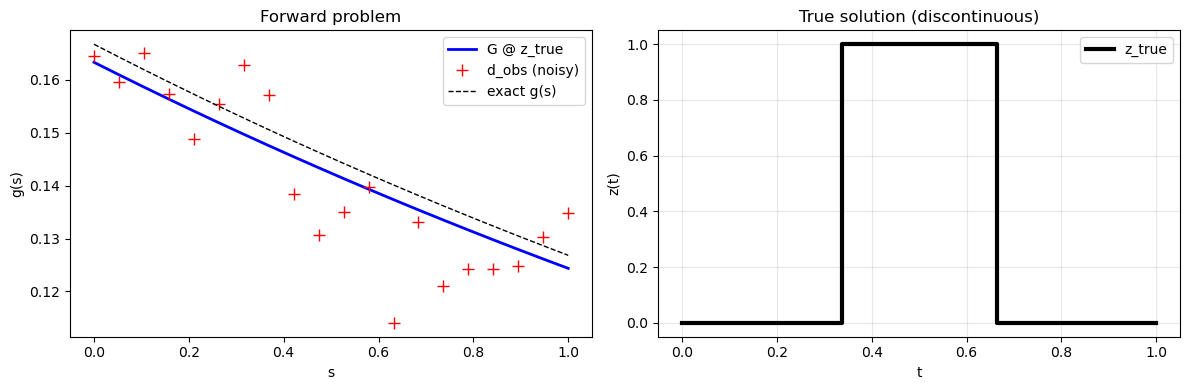

In [5]:

# quick sanity plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s, g_clean, "b-", lw=2, label="G @ z_true")
axes[0].plot(s, d_obs,   "r+", ms=8, label="d_obs (noisy)")
axes[0].plot(s, rhs_exact(s), "k--", lw=1, label="exact g(s)")
axes[0].set_xlabel("s"); axes[0].set_ylabel("g(s)")
axes[0].set_title("Forward problem"); axes[0].legend()
axes[1].step(t, z_true, "k-", lw=3, where="mid", label="z_true")
axes[1].set_xlabel("t"); axes[1].set_ylabel("z(t)")
axes[1].set_title("True solution (discontinuous)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("forward_wing.png", dpi=150, bbox_inches="tight")
plt.show()

## Prior estimate $\mathbf z_0$ and $\mathbf{C}_{z,z}$

In [6]:
z0      = np.zeros(n)
sigma_z = 1
Cz = sigma_z**2 * np.eye(n)

# MAP ESTIMATE

In [7]:
def map_estimate(G, d_obs, z0, Cz, Cd_inv):
    """
    m_hat = m0 + (G^T Cd^{-1} G + Cm^{-1})^{-1} G^T Cd^{-1} (d - G m0)
    """
    Cz_inv = np.linalg.inv(Cz)
    A      = G.T @ Cd_inv @ G + Cz_inv
    rhs    = G.T @ Cd_inv @ (d_obs - G @ z0)
    z_MAP  = z0 + np.linalg.solve(A, rhs)
    return z_MAP

In [8]:
z_MAP    = map_estimate(G, d_obs, z0, Cz, Cd_inv)
np.savetxt(os.path.join("DATA","z_MAP.csv"), z_MAP, delimiter=",")

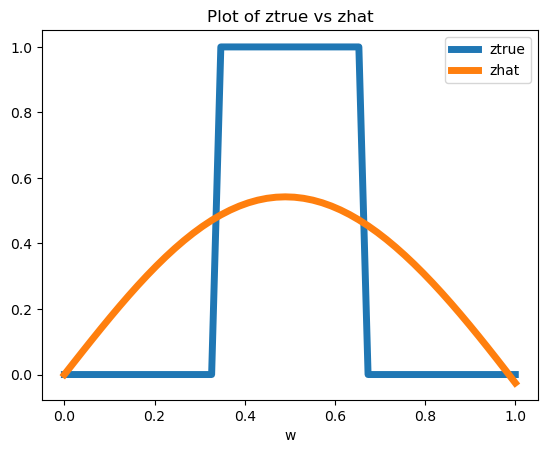

In [9]:
plt.figure(2); plt.clf()
plt.plot(t, z_true, label='ztrue', linewidth=5)
plt.plot(t, z_MAP, label='zhat', linewidth=5)
plt.title('Plot of ztrue vs zhat')
plt.xlabel('w')
plt.legend()

In [10]:
def generate_observations(z_samples, G, sigma_d, seed=11):
    """
    For each z_i in z, compute d_i = G(z_i) + eps_i.
    Returns d with shape (N, m).
    """
    rng  = np.random.default_rng(seed)
    N, n = z_samples.shape
    m    = G.shape[0]
    d    = np.zeros((N, m))
    for i in range(N):
        if i % 2000 == 0:
            print(f"  generating obs {i}/{N} ...", end="\r")
        d[i] = G @ z_samples[i] + rng.normal(0.0, sigma_d, size=m)
    print()
    return d

# Sampling from a Gaussian prior

In [11]:
def sample_gaussian_prior(n_samples, z0, Cz, seed = 10):
    z_gauss = multivariate_normal.rvs(mean = z0, cov = Cz, size = n_samples)
    return z_gauss

In [12]:

z_gauss = sample_gaussian_prior(n_samples, z0, Cz, seed = 10)
d_gauss = generate_observations(z_gauss, G, sigma_d, seed=11)

np.savetxt(os.path.join("DATA","z_gaussian.csv"), z_gauss, delimiter=",")
np.savetxt(os.path.join("DATA","d_gaussian.csv"), d_gauss, delimiter=",")

  generating obs 98000/100000 ...


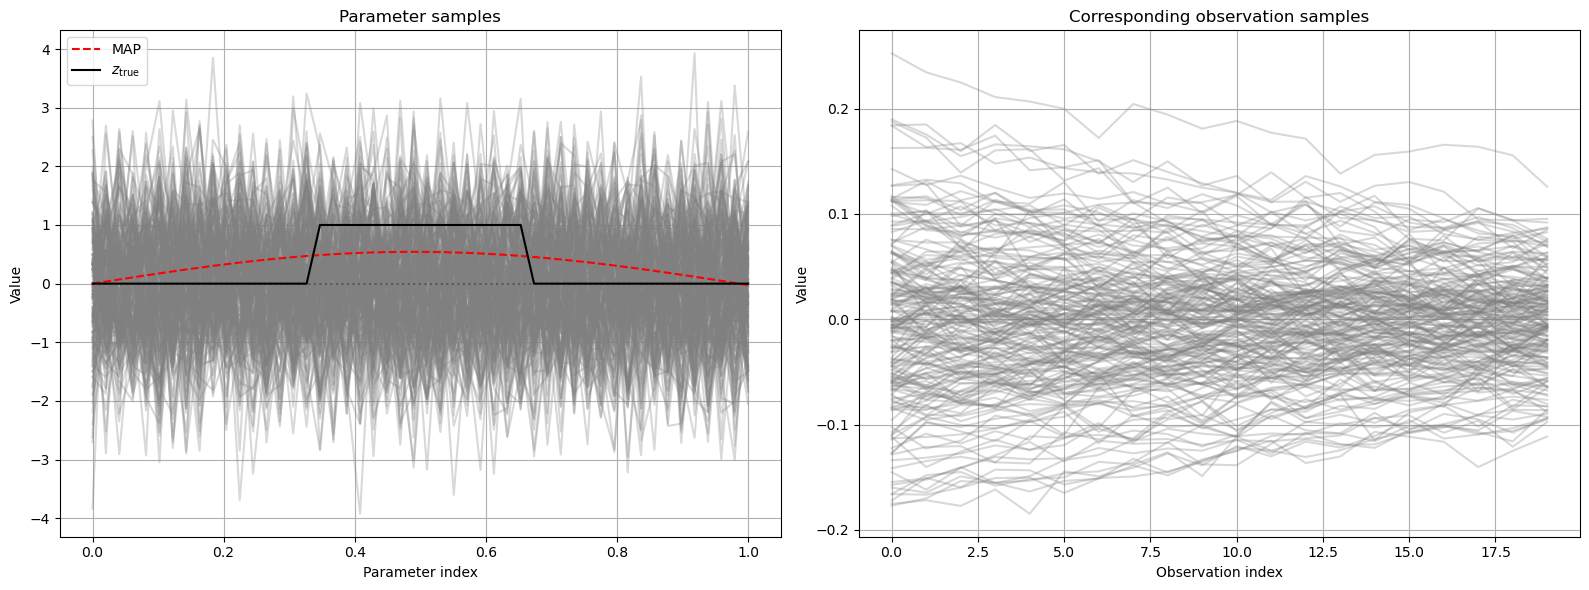

In [13]:
plt.figure(figsize=(16, 6))
plt.clf()
# --- Parameter samples ---
plt.subplot(1, 2, 1)
for i in range(min(200, n_samples)):
    plt.plot(t,z_gauss[i], color='gray', alpha=0.3)
plt.plot(t,z0, "k:", alpha=0.3)
plt.plot(t,z_MAP, "r--", lw=1.5, label=f"MAP")
plt.plot(t,z_true, "k-", lw=1.5, label=r"$z_{\rm true}$")

plt.xlabel('Parameter index')
plt.ylabel('Value')
plt.title('Parameter samples')
plt.legend()
plt.grid(True)

# --- Observation samples ---
plt.subplot(1, 2, 2)
for i in range(min(200, n_samples)):
    plt.plot(d_gauss[i], color='gray', alpha=0.3)

plt.xlabel('Observation index')
plt.ylabel('Value')
plt.title('Corresponding observation samples')
plt.grid(True)

plt.tight_layout()
plt.show()


# Sampling from a Laplace prior

In [14]:
def sample_laplace_prior(n_samples, z0, sigma_z, seed=20):

    rng = np.random.default_rng(seed)
    n = z0.size
    b = sigma_z / np.sqrt(2)

    eta = rng.laplace(0.0, b, size=(n_samples, n))
    z = z0.reshape(1, -1) + eta
    
    return z

In [15]:
z_laplace = sample_laplace_prior(n_samples, z0, sigma_z, seed=20)
d_laplace = generate_observations(z_laplace, G, sigma_d, seed=21)

np.savetxt(os.path.join("DATA","z_laplace.csv"), z_laplace, delimiter=",")
np.savetxt(os.path.join("DATA","d_laplace.csv"), d_laplace, delimiter=",")

  generating obs 98000/100000 ...


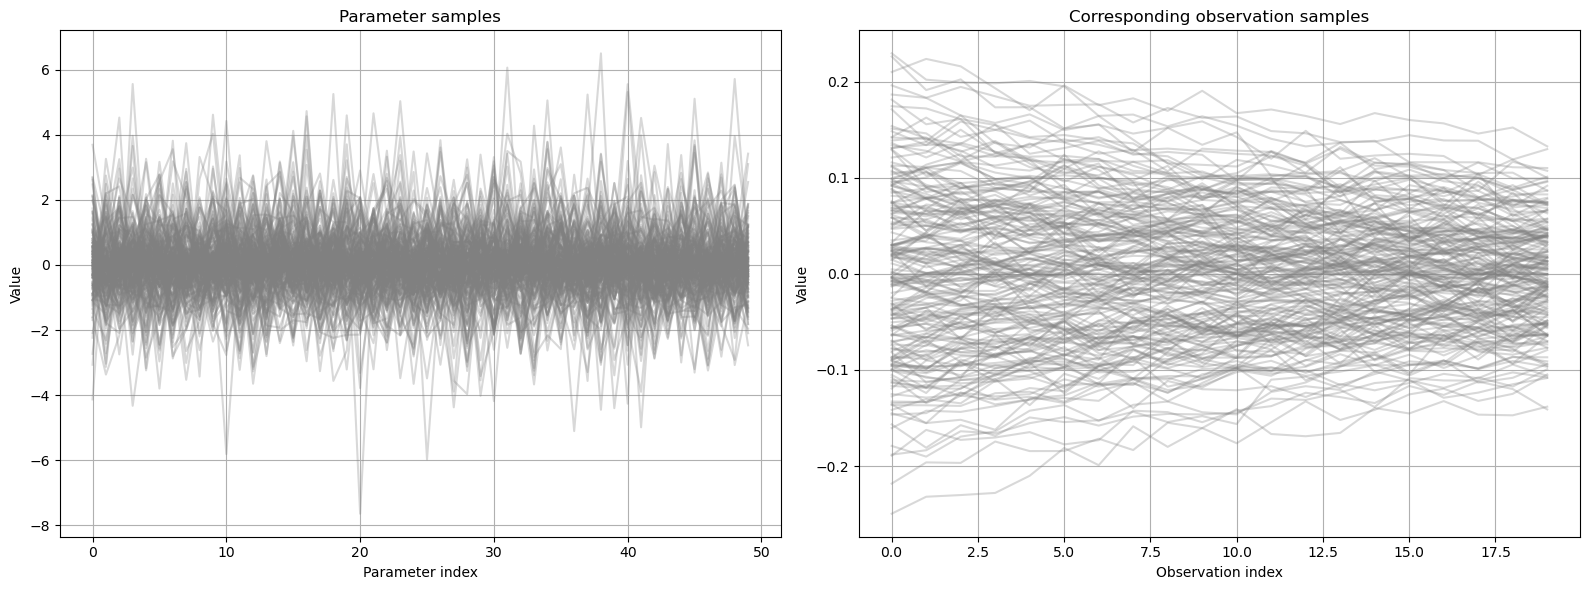

In [16]:
plt.figure(figsize=(16, 6))

# --- Subplot 1: Parameter samples ---
plt.subplot(1, 2, 1)
for i in range(min(200, n_samples)):
    plt.plot(z_laplace[i], color='gray', alpha=0.3)

plt.xlabel('Parameter index')
plt.ylabel('Value')
plt.title('Parameter samples')
plt.grid(True)

# --- Subplot 2: Observation samples ---
plt.subplot(1, 2, 2)
for i in range(min(200, n_samples)):
    plt.plot(d_laplace[i], color='gray', alpha=0.3)

plt.xlabel('Observation index')
plt.ylabel('Value')
plt.title('Corresponding observation samples')
plt.grid(True)

plt.tight_layout()
plt.show()


# Sampling from a total Variation prior

In [17]:
def sample_tv(n_samples, z0, sigma_z, seed=10):
    rng = np.random.default_rng(seed)
    n = z0.size
    z = np.zeros((n_samples, n))
    b_grad = 1.0 / np.sqrt(2 * n)   # raw, unscaled

    for i in range(n_samples):
        u = np.zeros(n)
        for k in range(n - 1):
            u[k + 1] = u[k] + rng.laplace(0.0, b_grad)
        u -= np.mean(u)
        z[i] = z0 + u

    # Rescale perturbations so the global std equals sigma_z.
    perturb  = z - z0.reshape(1, -1)          # (N, n)
    # std of each component across samples, then average across components
    mean_marginal_std = perturb.std(axis=0).mean()
    perturb *= sigma_z / mean_marginal_std
    z = z0.reshape(1, -1) + perturb
    return z

In [18]:
b_grad = sigma_z / np.sqrt(2 * n) 

z_tv = sample_tv(n_samples, z0, sigma_z, seed=30)
d_tv = generate_observations(z_tv, G, sigma_d, seed=31)

np.savetxt(os.path.join("DATA","z_tv.csv"), z_tv, delimiter=",")
np.savetxt(os.path.join("DATA","d_tv.csv"), d_tv, delimiter=",")

  generating obs 98000/100000 ...


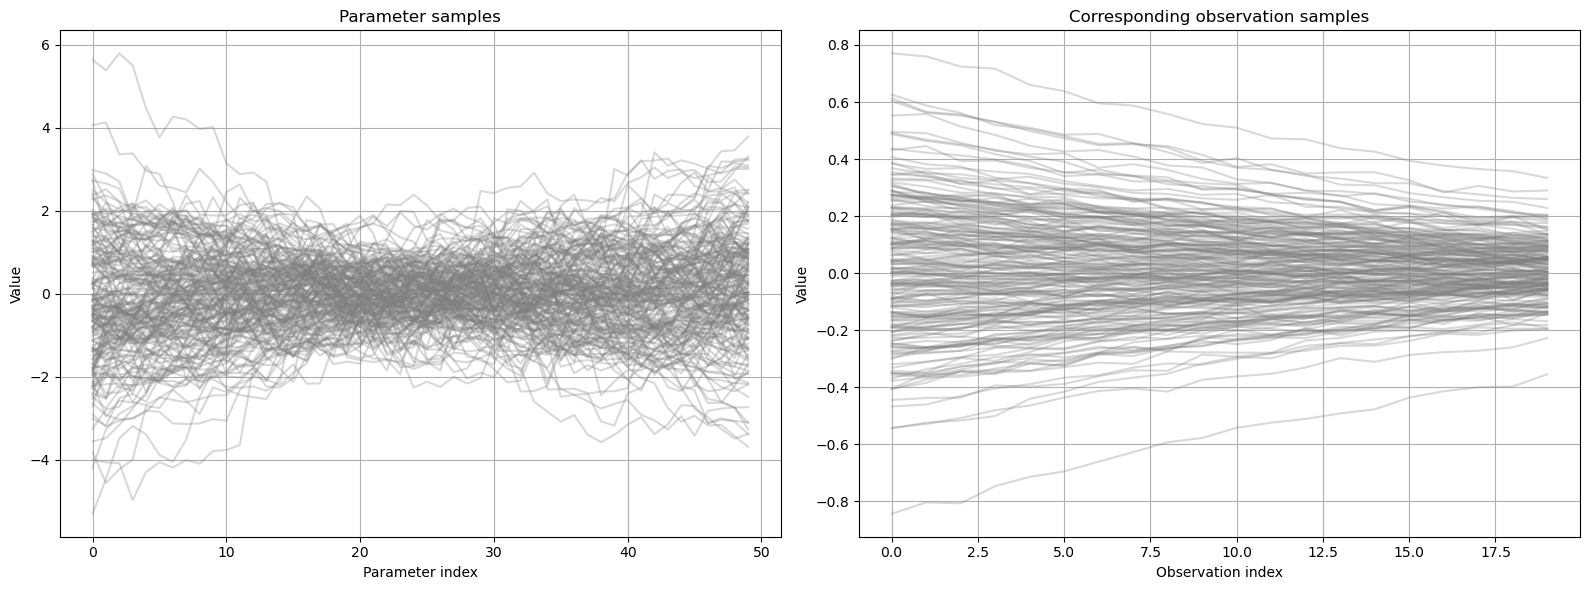

In [19]:
plt.figure(figsize=(16, 6))

# --- Subplot 1: Parameter samples ---
plt.subplot(1, 2, 1)
for i in range(min(200, n_samples)):
    plt.plot(z_tv[i], color='gray', alpha=0.3)

plt.xlabel('Parameter index')
plt.ylabel('Value')
plt.title('Parameter samples')
plt.grid(True)

# --- Subplot 2: Observation samples ---
plt.subplot(1, 2, 2)
for i in range(min(200, n_samples)):
    plt.plot(d_tv[i], color='gray', alpha=0.3)

plt.xlabel('Observation index')
plt.ylabel('Value')
plt.title('Corresponding observation samples')
plt.grid(True)

plt.tight_layout()
plt.show()


# Uniform samples

In [20]:
def sample_uniform_prior(n_samples, z0, a_uniform, seed=40):
    """
    Draw N samples from independent uniform prior:
   z     z_j ~ Uniform(z0_j - a, z0_j + a)
    
    a chosen so marginal std matches sigma_z:
        Var(Uniform(-a, a)) = a^2 / 3  =>  a = sigma_z * sqrt(3)
    Returns Z shape (N, n)
    """
    rng = np.random.default_rng(seed)
    n = z0.size
    eta = rng.uniform(-a_uniform, a_uniform, size=(n_samples, n))
    z = z0.reshape(1, -1) + eta
    return z

In [21]:
a_uniform = sigma_z * np.sqrt(3)   # ~3.46 for sigma_z = 2

z_uniform = sample_uniform_prior(n_samples, z0, a_uniform, seed=40)
d_uniform = generate_observations(z_uniform, G, sigma_d, seed=41)

np.savetxt(os.path.join("DATA","z_uniform.csv"), z_uniform, delimiter=",")
np.savetxt(os.path.join("DATA","d_uniform.csv"), d_uniform, delimiter=",")

  generating obs 98000/100000 ...


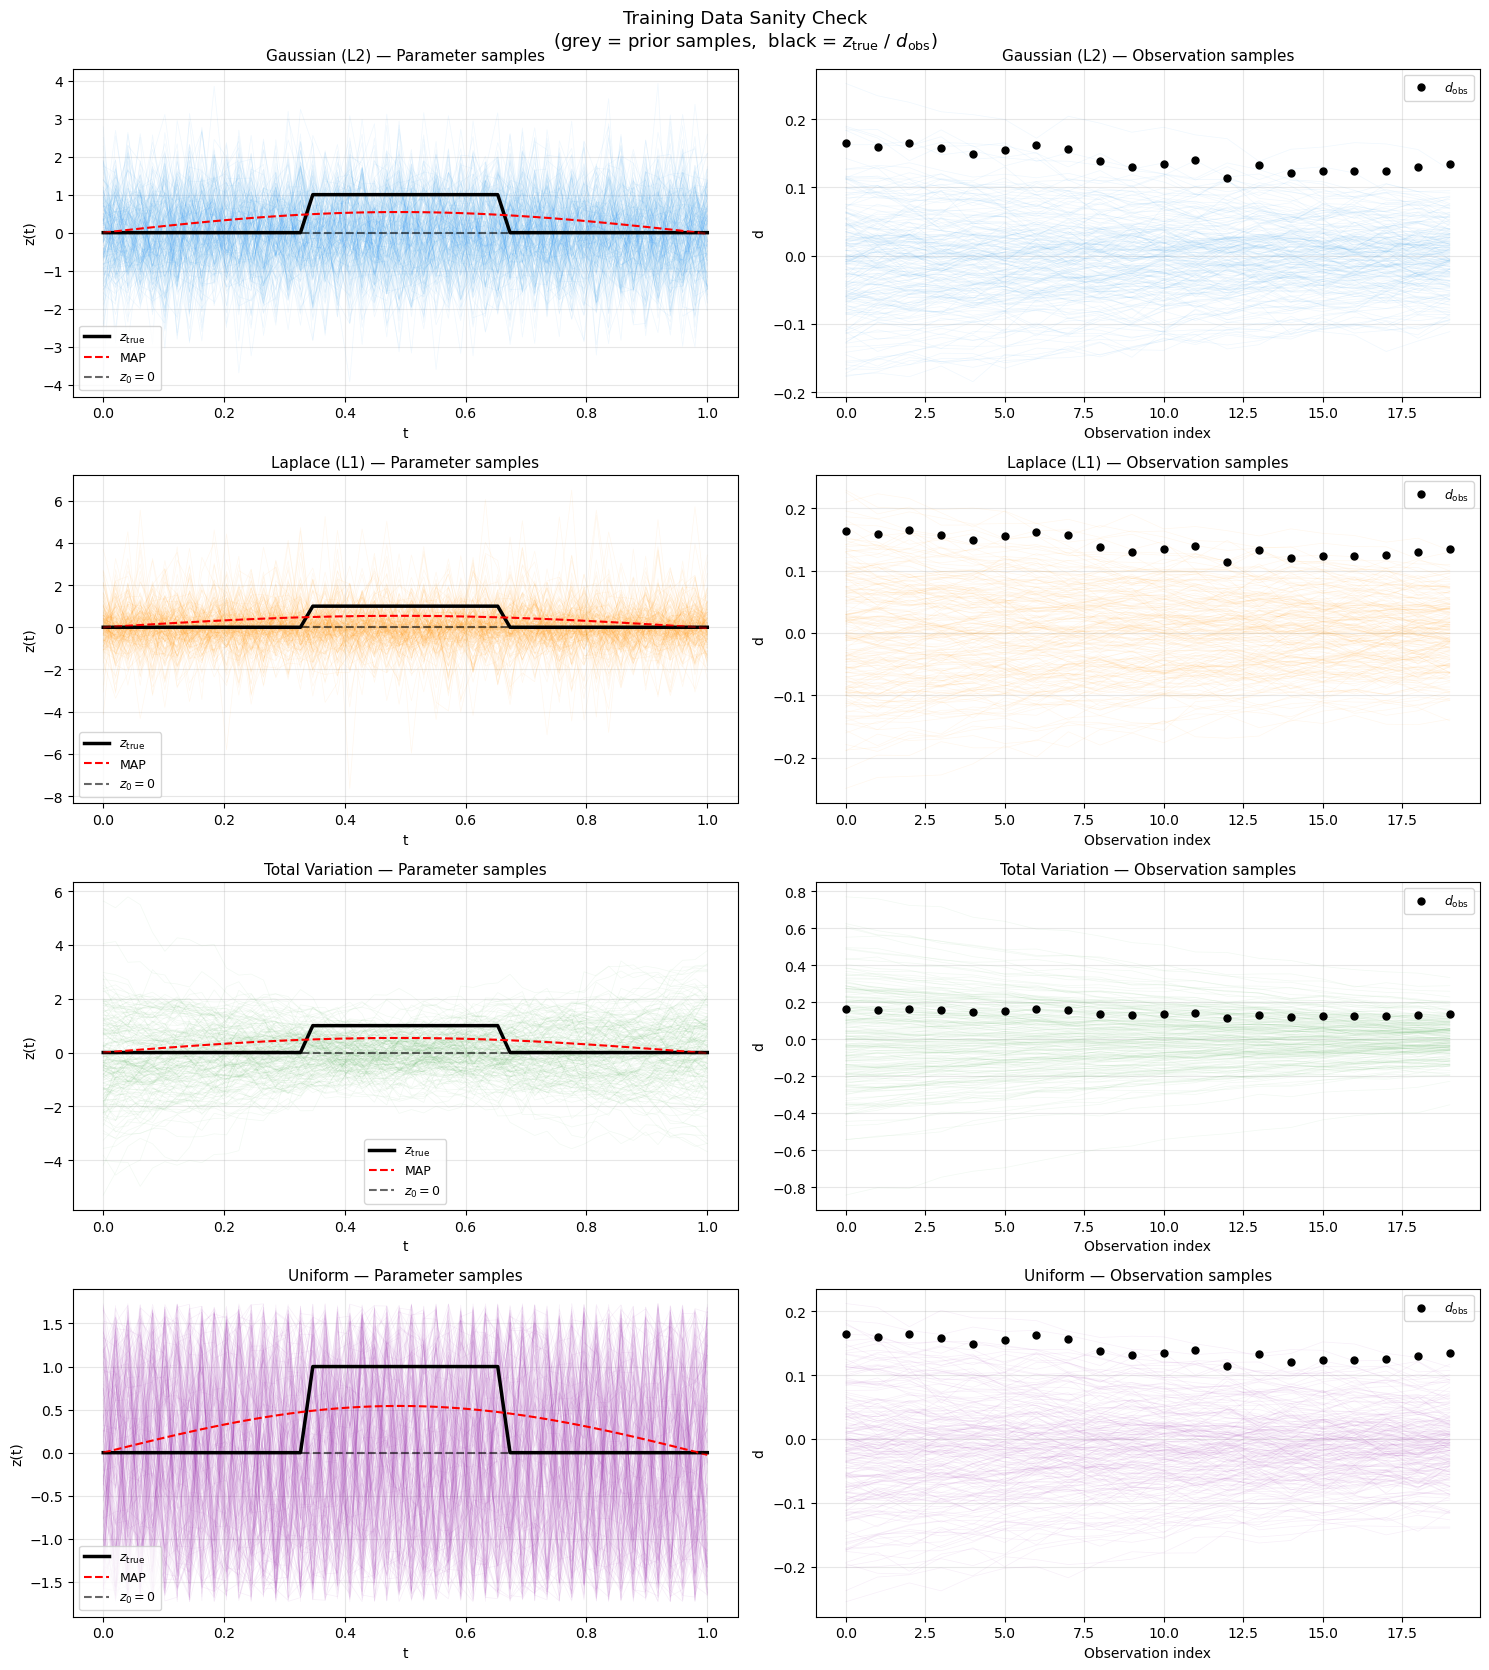

In [22]:
# ──────────────────────────────────────────────────────────
# 8.  Print statistics — confirm comparable variance
# ──────────────────────────────────────────────────────────

datasets = [
    ("Gaussian (L2)",    z_gauss, d_gauss, "#2196F3"),
    ("Laplace (L1)",     z_laplace,  d_laplace,  "#FF9800"),
    ("Total Variation",  z_tv,       d_tv,        "#4CAF50"),
    ("Uniform",          z_uniform,  d_uniform,   "#9C27B0"),  # new
]
fig = plt.figure(figsize=(15, 17))

for row, (label, zs, ds, color) in enumerate(datasets):

    # Parameter samples
    plt.subplot(4, 2, row * 2 + 1)
    for i in range(min(200, n_samples)):
        plt.plot(t, zs[i], color=color, alpha=0.07, linewidth=0.5)
    plt.plot(t, z_true, "k-",  linewidth=2.5, label=r"$z_{\rm true}$")
    plt.plot(t, z_MAP,  "r--", linewidth=1.5, label="MAP")
    plt.plot(t, z0,     "k--", linewidth=1.5, label=r"$z_0 = 0$", alpha=0.6)
    plt.title(f"{label} — Parameter samples", fontsize=11)
    plt.xlabel("t"); plt.ylabel("z(t)")
    plt.legend(fontsize=9); plt.grid(True, alpha=0.3)

    # Observation samples
    plt.subplot(4, 2, row * 2 + 2)
    for i in range(min(200, n_samples)):
        plt.plot(ds[i], color=color, alpha=0.07, linewidth=0.5)
    plt.plot(d_obs, "ko", markersize=5, label=r"$d_{\rm obs}$", zorder=5)
    plt.title(f"{label} — Observation samples", fontsize=11)
    plt.xlabel("Observation index"); plt.ylabel("d")
    plt.legend(fontsize=9); plt.grid(True, alpha=0.3)

plt.suptitle("Training Data Sanity Check\n"
             r"(grey = prior samples,  black = $z_{\rm true}$ / $d_{\rm obs}$)",
             fontsize=13)
plt.tight_layout()
# plt.savefig("sanity_check.png", dpi=150)
plt.show()

In [23]:
print("\n" + "="*52)
print(f"  {'Dataset':<22}  {'z std':>8}  {'d std':>8}")
print("="*52)
for label, zs, ds, _ in datasets:
    print(f"  {label:<22}  {zs.std():>8.3f}  {ds.std():>8.3f}")
print("="*52)
print("\nAll CSV files ready. Run nn_inverse.py next.\n")



  Dataset                    z std     d std
  Gaussian (L2)              1.000     0.066
  Laplace (L1)               1.000     0.066
  Total Variation            1.025     0.163
  Uniform                    1.000     0.066

All CSV files ready. Run nn_inverse.py next.

